# Airline Passenger Satisfaction — GA + GridSearch
### Düzeltilmiş Versiyon
**Yapılan düzeltmeler:**
- ✅ Data leakage giderildi (fitness fonksiyonu artık cross-validation kullanıyor)
- ✅ Fitness cache eklendi (performans artışı)
- ✅ `satisfaction` sütunu ayrı tutularak scale edilmiyor
- ✅ GridSearch parametre aralığı genişletildi

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from warnings import filterwarnings
import random
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report, roc_curve
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

filterwarnings('ignore')
random.seed(42)
np.random.seed(42)

## 1. Veri Yükleme ve Ön İşleme

In [2]:
train_data=pd.read_csv(r"data/train.csv")
test_data=pd.read_csv(r"data/test.csv")

all_data = pd.concat((
    train_data.loc[:, "Gender":"satisfaction"],
    test_data.loc[:,  "Gender":"satisfaction"]
))

print("Eksik değerler:")
print(all_data.isnull().sum())

Eksik değerler:
Gender                                 0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Inflight wifi service                  0
Departure/Arrival time convenient      0
Ease of Online booking                 0
Gate location                          0
Food and drink                         0
Online boarding                        0
Seat comfort                           0
Inflight entertainment                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Inflight service                       0
Cleanliness                            0
Departure Delay in Minutes             0
Arrival Delay in Minutes             393
satisfaction                           0
dtype: int64


In [3]:
# Eksik değerleri doldur
all_data["Arrival Delay in Minutes"] = all_data["Arrival Delay in Minutes"].fillna(
    all_data["Arrival Delay in Minutes"].median()
)

In [4]:
# Kategorik değişkenleri encode et
label_encoder = LabelEncoder()

all_data["satisfaction"] = label_encoder.fit_transform(all_data["satisfaction"].str.strip())

cat_cols = ["Gender", "Customer Type", "Type of Travel", "Class"]
for col in cat_cols:
    all_data[col] = label_encoder.fit_transform(all_data[col].str.strip())

all_data.head()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,1,0,13,1,2,460,3,4,3,1,...,5,4,3,4,4,5,5,25,18.0,0
1,1,1,25,0,0,235,3,2,3,3,...,1,1,5,3,1,4,1,1,6.0,0
2,0,0,26,0,0,1142,2,2,2,2,...,5,4,3,4,4,4,5,0,0.0,1
3,0,0,25,0,0,562,2,5,5,5,...,2,2,5,3,1,4,2,11,9.0,0
4,1,0,61,0,0,214,3,3,3,3,...,3,3,4,4,3,3,3,0,0.0,1


In [5]:
# ✅ DÜZELTME: satisfaction'ı ayrı tut, sadece feature'ları scale et
# ❌ ESKİ KOD: data_scaled = minmax_scaler.fit_transform(all_data)  → satisfaction da scale ediliyordu

X_raw = all_data.drop("satisfaction", axis=1)
y = all_data["satisfaction"]  # 0 ve 1 değerleri, scale gerekmez

minmax_scaler = MinMaxScaler()
X_scaled = pd.DataFrame(
    minmax_scaler.fit_transform(X_raw),
    columns=X_raw.columns
)

feature_names = X_scaled.columns
print("Feature sayısı:", len(feature_names))
print("y benzersiz değerleri:", y.unique())
X_scaled.head()

Feature sayısı: 22
y benzersiz değerleri: [0 1]


,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
0,1.0,0.0,0.076923,1.0,1.0,0.086632,0.6,0.8,0.6,0.2,...,1.0,1.0,0.8,0.6,0.75,0.8,1.0,1.0,0.015704,0.011364
1,1.0,1.0,0.230769,0.0,0.0,0.041195,0.6,0.4,0.6,0.6,...,0.2,0.2,0.2,1.0,0.50,0.2,0.8,0.2,0.000628,0.003788
2,0.0,0.0,0.243590,0.0,0.0,0.224354,0.4,0.4,0.4,0.4,...,1.0,1.0,0.8,0.6,0.75,0.8,0.8,1.0,0.000000,0.000000
3,0.0,0.0,0.230769,0.0,0.0,0.107229,0.4,1.0,1.0,1.0,...,0.4,0.4,0.4,1.0,0.50,0.2,0.8,0.4,0.006910,0.005682
4,1.0,0.0,0.692308,0.0,0.0,0.036955,0.6,0.6,0.6,0.6,...,1.0,0.6,0.6,0.8,0.75,0.6,0.6,0.6,0.000000,0.000000


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (90916, 22), Test: (38964, 22)


## 2. Genetik Algoritma — Özellik Seçimi

**Kromozom:** Her gen = bir özellik (1: seçili, 0: seçili değil)

In [7]:
POP_SIZE     = 15
GENS         = 8
MUTATION_RATE = 0.1

num_features = X_train.shape[1]

In [8]:
# ✅ DÜZELTME 1: Cross-validation ile fitness — data leakage yok
# ✅ DÜZELTME 2: Cache ile tekrar hesaplamayı önle

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fitness_cache = {}

def create_individual():
    return [random.randint(0, 1) for _ in range(num_features)]

def fitness(individual):
    key = tuple(individual)
    if key in fitness_cache:
        return fitness_cache[key]   # Cache'den al, yeniden hesaplama

    selected = [i for i in range(len(individual)) if individual[i] == 1]
    if len(selected) == 0:
        return 0

    X_sub = X_train.iloc[:, selected]

    # ✅ Cross-validation — test seti HİÇ kullanılmıyor
    # ❌ ESKİ KOD: model.fit(X_tr, y_train); roc_auc_score(y_test, probs)  → data leakage!
    model = RandomForestClassifier(n_estimators=50, max_depth=10, n_jobs=-1, random_state=42)
    score = cross_val_score(model, X_sub, y_train, cv=cv, scoring='roc_auc').mean()

    fitness_cache[key] = score
    return score

def selection(pop, scores):
    """Tournament selection — önceden hesaplanmış scores kullanır"""
    # ✅ DÜZELTME 3: Fitness yeniden hesaplanmıyor, scores listesi kullanılıyor
    # ❌ ESKİ KOD: sorted(selected, key=lambda x: fitness(x)) → her seferinde yeniden hesaplıyordu
    k = 3
    indices = random.sample(range(len(pop)), k)
    best_idx = max(indices, key=lambda i: scores[i])
    return pop[best_idx][:]

def crossover(p1, p2):
    point = random.randint(1, num_features - 1)
    return p1[:point] + p2[point:]

def mutation(ind):
    for i in range(len(ind)):
        if random.random() < MUTATION_RATE:
            ind[i] = 1 - ind[i]
    return ind

In [9]:
# Ana GA döngüsü
population = [create_individual() for _ in range(POP_SIZE)]

best_individual = None
best_score = 0
best_score_history = []

print("=" * 50)
print("GA ile Özellik Seçimi Başlıyor...")
print("=" * 50)

for gen in range(GENS):
    # ✅ Tüm fitness değerlerini bir kerede hesapla (cache sayesinde hızlı)
    scores = [fitness(ind) for ind in population]

    # En iyiyi güncelle
    for ind, score in zip(population, scores):
        if score > best_score:
            best_score = score
            best_individual = ind[:]

    best_score_history.append(best_score)
    n_selected = sum(best_individual)
    print(f"Gen {gen+1:02d} | Best ROC-AUC (CV): {best_score:.4f} | Seçilen feature: {n_selected}/{num_features}")

    # Yeni nesil
    new_pop = []
    for _ in range(POP_SIZE):
        p1 = selection(population, scores)
        p2 = selection(population, scores)
        child = crossover(p1, p2)
        child = mutation(child)
        new_pop.append(child)

    population = new_pop

print("\nGA tamamlandı!")
print(f"Cache'deki benzersiz kromozom sayısı: {len(fitness_cache)}")

GA ile Özellik Seçimi Başlıyor...
Gen 01 | Best ROC-AUC (CV): 0.9871 | Seçilen feature: 8/22
Gen 02 | Best ROC-AUC (CV): 0.9889 | Seçilen feature: 9/22
Gen 03 | Best ROC-AUC (CV): 0.9890 | Seçilen feature: 9/22
Gen 04 | Best ROC-AUC (CV): 0.9890 | Seçilen feature: 9/22
Gen 05 | Best ROC-AUC (CV): 0.9890 | Seçilen feature: 9/22
Gen 06 | Best ROC-AUC (CV): 0.9890 | Seçilen feature: 9/22
Gen 07 | Best ROC-AUC (CV): 0.9890 | Seçilen feature: 9/22
Gen 08 | Best ROC-AUC (CV): 0.9890 | Seçilen feature: 9/22

GA tamamlandı!
Cache'deki benzersiz kromozom sayısı: 118


In [10]:
# Seçilen özellikler
selected_features = [i for i in range(len(best_individual)) if best_individual[i] == 1]
print("Seçilen feature sayısı:", len(selected_features))
print("Feature isimleri:", feature_names[selected_features].tolist())

Seçilen feature sayısı: 9
Feature isimleri: ['Customer Type', 'Type of Travel', 'Class', 'Inflight wifi service', 'Gate location', 'Seat comfort', 'Inflight entertainment', 'Baggage handling', 'Inflight service']


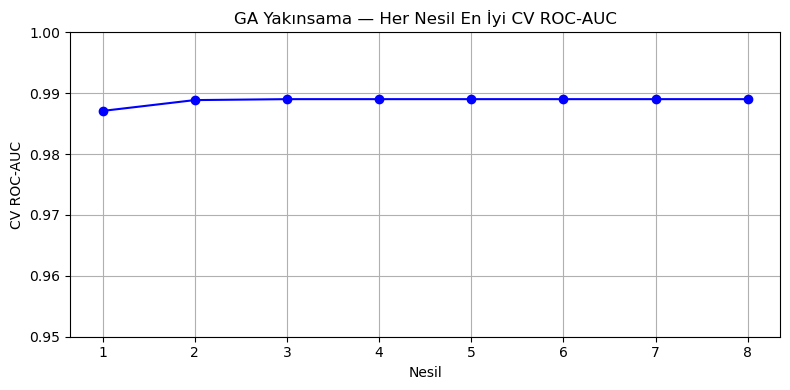

In [11]:
# GA yakınsama grafiği
plt.figure(figsize=(8, 4))
plt.plot(range(1, GENS+1), best_score_history, 'b-o', markersize=6)
plt.title('GA Yakınsama — Her Nesil En İyi CV ROC-AUC')
plt.xlabel('Nesil')
plt.ylabel('CV ROC-AUC')
plt.ylim(0.95, 1.0)
plt.grid(True)
plt.tight_layout()
plt.show()

## 3. GridSearch — Hiperparametre Optimizasyonu

GA'nın bulduğu feature seti üzerinde RF hiperparametrelerini optimize et.

In [12]:
selected_feature_names = X_train.columns[selected_features].tolist()
print("Seçilen features:", selected_feature_names)

# Ham veriyi al ve yeni scaler fit et
x_raw_selected = X_raw[selected_feature_names]
scaler_genetic = MinMaxScaler()
X_all_scaled = pd.DataFrame(
    scaler_genetic.fit_transform(x_raw_selected),
    columns=selected_feature_names
)

# Yeniden split
X_tr, X_te, y_tr, y_te = train_test_split(
    X_all_scaled, y, test_size=0.3, random_state=42, stratify=y
)

param_grid = {
    "n_estimators":      [100, 200, 300],
    "max_depth":         [None, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf":  [1, 2, 4]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

grid.fit(X_tr, y_tr)
best_model = grid.best_estimator_
print("En iyi parametreler:", grid.best_params_)

import pickle
pickle.dump({
    "model":    best_model,
    "scaler":   scaler_genetic,
    "features": selected_feature_names
}, open(r"model_genetic.pkl", "wb"))

print("✅ Kaydedildi:", selected_feature_names)

Seçilen features: ['Customer Type', 'Type of Travel', 'Class', 'Inflight wifi service', 'Gate location', 'Seat comfort', 'Inflight entertainment', 'Baggage handling', 'Inflight service']
Fitting 5 folds for each of 81 candidates, totalling 405 fits
En iyi parametreler: {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 300}
✅ Kaydedildi: ['Customer Type', 'Type of Travel', 'Class', 'Inflight wifi service', 'Gate location', 'Seat comfort', 'Inflight entertainment', 'Baggage handling', 'Inflight service']


## 4. Model Değerlendirme (Test Seti)

In [13]:
preds = best_model.predict(X_te)
probs = best_model.predict_proba(X_te)[:, 1]

acc = accuracy_score(y_test, preds)
roc = roc_auc_score(y_test, probs)

print(f"Accuracy : {acc:.4f}")
print(f"ROC-AUC  : {roc:.4f}")

Accuracy : 0.9542
ROC-AUC  : 0.9918


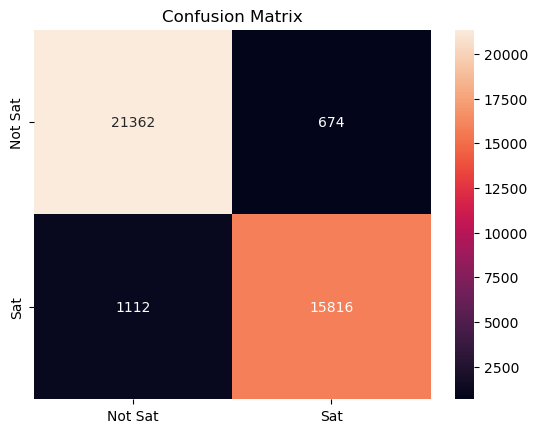

In [14]:
cm = confusion_matrix(y_test, preds)
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["Not Sat", "Sat"],
            yticklabels=["Not Sat", "Sat"])
plt.title("Confusion Matrix")
plt.show()

In [15]:
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.95      0.97      0.96     22036
           1       0.96      0.93      0.95     16928

    accuracy                           0.95     38964
   macro avg       0.95      0.95      0.95     38964
weighted avg       0.95      0.95      0.95     38964



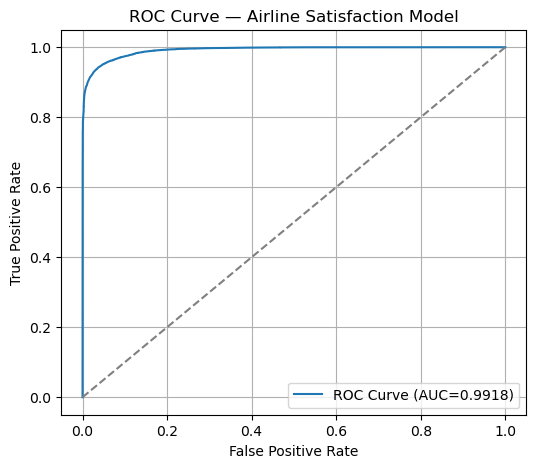

In [16]:
fpr, tpr, thresholds = roc_curve(y_test, probs)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC={roc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Airline Satisfaction Model")
plt.legend()
plt.grid()
plt.show()

In [17]:
import pickle

pickle.dump({
    "model": best_model,
    "scaler": scaler_genetic,
    "features": selected_feature_names  # ✅ doğru değişken adı
}, open(r"model_genetic.pkl", "wb"))

print("✅ Kaydedildi:", selected_feature_names)

✅ Kaydedildi: ['Customer Type', 'Type of Travel', 'Class', 'Inflight wifi service', 'Gate location', 'Seat comfort', 'Inflight entertainment', 'Baggage handling', 'Inflight service']


In [18]:
print(feature_names[selected_features].tolist())
print(len(selected_features))

['Customer Type', 'Type of Travel', 'Class', 'Inflight wifi service', 'Gate location', 'Seat comfort', 'Inflight entertainment', 'Baggage handling', 'Inflight service']
9


In [19]:
import pickle

# Mevcut pkl'de ne var kontrol et
loaded = pickle.load(open(r"model_genetic.pkl", "rb"))
print("Features:", loaded["features"])
print("Tip:", type(loaded["features"][0]))  # str mi int mi?

Features: ['Customer Type', 'Type of Travel', 'Class', 'Inflight wifi service', 'Gate location', 'Seat comfort', 'Inflight entertainment', 'Baggage handling', 'Inflight service']
Tip: <class 'str'>


In [20]:
import pickle
loaded = pickle.load(open(r"model_genetic.pkl", "rb"))
print("Features:", loaded["features"])
print("Scaler n_features:", loaded["scaler"].n_features_in_)
print("Model n_features:", loaded["model"].n_features_in_)

Features: ['Customer Type', 'Type of Travel', 'Class', 'Inflight wifi service', 'Gate location', 'Seat comfort', 'Inflight entertainment', 'Baggage handling', 'Inflight service']
Scaler n_features: 9
Model n_features: 9


In [21]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

train_data=pd.read_csv(r"data/train.csv")
test_data=pd.read_csv(r"data/test.csv")

all_data = pd.concat((
    train_data.loc[:, "Gender":"satisfaction"],
    test_data.loc[:,  "Gender":"satisfaction"]
)).reset_index(drop=True)

all_data["Arrival Delay in Minutes"] = all_data["Arrival Delay in Minutes"].fillna(all_data["Arrival Delay in Minutes"].median())

le = LabelEncoder()
all_data["satisfaction"] = le.fit_transform(all_data["satisfaction"].str.strip())
for col in ["Gender", "Customer Type", "Type of Travel", "Class"]:
    all_data[col] = le.fit_transform(all_data[col].str.strip())

x_raw = all_data.drop("satisfaction", axis=1)
print(x_raw.columns.tolist())

['Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']


In [22]:

import pickle

dosyalar = {
    "Genetik":       r"model_genetic.pkl"
}

for name, path in dosyalar.items():
    loaded = pickle.load(open(path, "rb"))
    print(f"{name} — Scaler: {loaded['scaler'].n_features_in_} | Model: {loaded['model'].n_features_in_}")

Genetik — Scaler: 9 | Model: 9


In [ ]:
import pickle
import numpy as np

loaded = pickle.load(open("model_genetic.pkl", "rb"))
model = loaded["model"]
scaler = loaded["scaler"]
features = loaded["features"]


test_cases = [
    # [Customer Type, Type of Travel, Class, wifi, gate, seat, entertainment, baggage, inflight_svc]
    [0, 0, 0, 5, 5, 5, 5, 5, 5],  # Loyal, Business, Business class, all 5
    [1, 1, 2, 1, 1, 1, 1, 1, 1],  # Disloyal, Personal, Eco, all 1
    [0, 1, 2, 3, 3, 3, 3, 3, 3],  # Loyal, Personal, Eco, all 3
]

import pandas as pd
for tc in test_cases:
    df = pd.DataFrame([tc], columns=features)
    scaled = scaler.transform(df)
    pred = model.predict(scaled)
    prob = model.predict_proba(scaled)[0]
    print(f"Input: {tc} → pred={pred[0]}, prob_not_sat={prob[0]:.3f}, prob_sat={prob[1]:.3f}")

Input: [0, 0, 0, 5, 5, 5, 5, 5, 5] → pred=1, prob_not_sat=0.000, prob_sat=1.000
Input: [1, 1, 2, 1, 1, 1, 1, 1, 1] → pred=0, prob_not_sat=0.979, prob_sat=0.021
Input: [0, 1, 2, 3, 3, 3, 3, 3, 3] → pred=0, prob_not_sat=0.999, prob_sat=0.001


In [ ]:
import pickle
import pandas as pd
import numpy as np

loaded = pickle.load(open("model_genetic.pkl", "rb"))
model = loaded["model"]
scaler = loaded["scaler"]
features = loaded["features"]

print("Genetik features:", features)
print()
print("Scaler data_min_:", scaler.data_min_)
print("Scaler data_max_:", scaler.data_max_)


input_dict = {
    "Gender": 0, "Customer Type": 0, "Age": 30,
    "Type of Travel": 0, "Class": 0, "Flight Distance": 1000,
    "Inflight wifi service": 3,
    "Departure/Arrival time convenient": 3,
    "Ease of Online booking": 3,
    "Gate location": 3, "Food and drink": 3,
    "Online boarding": 3, "Seat comfort": 3,
    "Inflight entertainment": 3, "On-board service": 3,
    "Leg room service": 3, "Baggage handling": 3,
    "Checkin service": 3, "Inflight service": 3,
    "Cleanliness": 3,
    "Departure Delay in Minutes": 0,
    "Arrival Delay in Minutes": 0,
}

df = pd.DataFrame([input_dict])
X_input = df[features]
print("\nModele giden ham değerler:")
print(X_input.to_string())

X_scaled = scaler.transform(X_input)
print("\nScale sonrası:")
print(pd.DataFrame(X_scaled, columns=features).to_string())

pred = model.predict(X_scaled)
prob = model.predict_proba(X_scaled)[0]
print(f"\npred={pred[0]}, prob_not={prob[0]:.3f}, prob_sat={prob[1]:.3f}")

Genetik features: ['Customer Type', 'Type of Travel', 'Class', 'Inflight wifi service', 'Gate location', 'Seat comfort', 'Inflight entertainment', 'Baggage handling', 'Inflight service']

Scaler data_min_: [0. 0. 0. 0. 0. 0. 0. 1. 0.]
Scaler data_max_: [1. 1. 2. 5. 5. 5. 5. 5. 5.]

Modele giden ham değerler:
   Customer Type  Type of Travel  Class  Inflight wifi service  Gate location  Seat comfort  Inflight entertainment  Baggage handling  Inflight service
0              0               0      0                      3              3             3                       3                 3                 3

Scale sonrası:
   Customer Type  Type of Travel  Class  Inflight wifi service  Gate location  Seat comfort  Inflight entertainment  Baggage handling  Inflight service
0            0.0             0.0    0.0                    0.6            0.6           0.6                     0.6               0.5               0.6

pred=0, prob_not=0.940, prob_sat=0.060
